# IDC Data Visualization

This notebook is the lightweight EDA step before training.

It reuses the saved cleaned artifacts from notebook `01_manifest_and_patient_split.ipynb` and focuses on:
- cleaning summary
- overall class balance
- split balance
- patient-level patch distribution
- patient-level positive-rate distribution
- random image grids for each class
- basic image sanity checks and pixel statistics


In [21]:
from google.colab import drive
from pathlib import Path
import sys

drive.mount('/content/drive')

# This notebook reads the cleaned artifacts produced by notebook 01.
PROJECT_ROOT = Path('/content/drive/MyDrive/Workshop UDL')
SRC_DIR = PROJECT_ROOT / 'src'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
DATASET_CACHE_DIR = PROJECT_ROOT / 'datasets'
DATASET_ARCHIVE_PATH = DATASET_CACHE_DIR / 'Breast Cancer Histopathology Dataset.zip'

RUNTIME_DIR = Path('/content/idc_runtime')
RUNTIME_EXTRACT_DIR = RUNTIME_DIR / 'dataset'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f'Source directory not found: {SRC_DIR}. '
        'Put the project folder in Google Drive so Colab can import src/idc_pipeline.'
    )

print(f'Project root: {PROJECT_ROOT}')
print(f'Artifacts dir: {ARTIFACTS_DIR}')
print(f'Dataset archive cache: {DATASET_ARCHIVE_PATH}')
print(f'Runtime extract dir: {RUNTIME_EXTRACT_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Workshop UDL
Artifacts dir: /content/drive/MyDrive/Workshop UDL/artifacts
Dataset archive cache: /content/drive/MyDrive/Workshop UDL/datasets/Breast Cancer Histopathology Dataset.zip
Runtime extract dir: /content/idc_runtime/dataset


In [22]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

from idc_pipeline import prepare_dataset_from_cached_zip

# Load the cleaned manifest and summary tables instead of rescanning the raw folders.
cleaning_summary_path = ARTIFACTS_DIR / 'cleaning_summary.json'
manifest_path = ARTIFACTS_DIR / 'manifest_with_split.csv'
patient_summary_path = ARTIFACTS_DIR / 'patient_summary.csv'
split_summary_path = ARTIFACTS_DIR / 'split_summary.csv'

required_artifacts = [
    cleaning_summary_path,
    manifest_path,
    patient_summary_path,
    split_summary_path,
]
missing_artifacts = [path for path in required_artifacts if not path.exists()]
if missing_artifacts:
    missing_text = '\n'.join(str(path) for path in missing_artifacts)
    raise FileNotFoundError(
        'Missing step-1 artifacts. Run notebook 01 first.\n'
        f'Missing files:\n{missing_text}'
    )

dataset_dir = prepare_dataset_from_cached_zip(
    archive_path=DATASET_ARCHIVE_PATH,
    extract_dir=RUNTIME_EXTRACT_DIR,
)

manifest_df = pd.read_csv(manifest_path)
patient_df = pd.read_csv(patient_summary_path)
split_summary_df = pd.read_csv(split_summary_path)
with cleaning_summary_path.open() as handle:
    cleaning_summary = json.load(handle)

manifest_df['full_path'] = manifest_df['relative_path'].map(lambda value: dataset_dir / value)

print(f'Dataset ready at: {dataset_dir}')
print(f'Manifest rows: {len(manifest_df):,}')
print(f'Patient rows: {len(patient_df):,}')
display(split_summary_df)


Using existing extracted dataset: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
Resolved canonical dataset directory: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
Dataset ready at: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
Manifest rows: 275,222
Patient rows: 279


,split,patients,patches,positive_patches,negative_patches,positive_rate
0,train,192,193281,55496,137785,0.287126
1,val,44,40963,11523,29440,0.281303
2,test,43,40978,11749,29229,0.286715


In [23]:
cleaning_overview_df = pd.DataFrame(
    [
        {
            'expected_patch_size': (
                f"{cleaning_summary['expected_patch_size']['width']}"
                f"x{cleaning_summary['expected_patch_size']['height']}"
            ),
            'scanned_patches': cleaning_summary['scanned_image_count'],
            'kept_patches': cleaning_summary['kept_image_count'],
            'dropped_patches': cleaning_summary['dropped_image_count'],
            'drop_rate_%': round(cleaning_summary['drop_fraction'] * 100, 3),
        }
    ]
)
display(cleaning_overview_df)

drop_reason_df = pd.DataFrame(
    [
        {'reason': reason, 'count': count}
        for reason, count in cleaning_summary['dropped_reason_counts'].items()
    ]
)

if drop_reason_df.empty:
    print('No samples were dropped during cleaning.')
else:
    display(drop_reason_df)
retained_rate = (1.0 - cleaning_summary['drop_fraction']) * 100
print(
    f"Cleaning kept {cleaning_summary['kept_image_count']:,} of "
    f"{cleaning_summary['scanned_image_count']:,} patches "
    f"({retained_rate:.2f}% retained)."
)


,expected_patch_size,scanned_patches,kept_patches,dropped_patches,drop_rate_%
0,50x50,277524,275222,2302,0.829


,reason,count
0,wrong_size,2302


Cleaning kept 275,222 of 277,524 patches (99.17% retained).


,patients,patches,class_0_patches,class_1_patches,class_1_rate
0,279,275222,196454,78768,0.286198


label,class 0,class 1
split,,
train,137785,55496
val,29440,11523
test,29229,11749


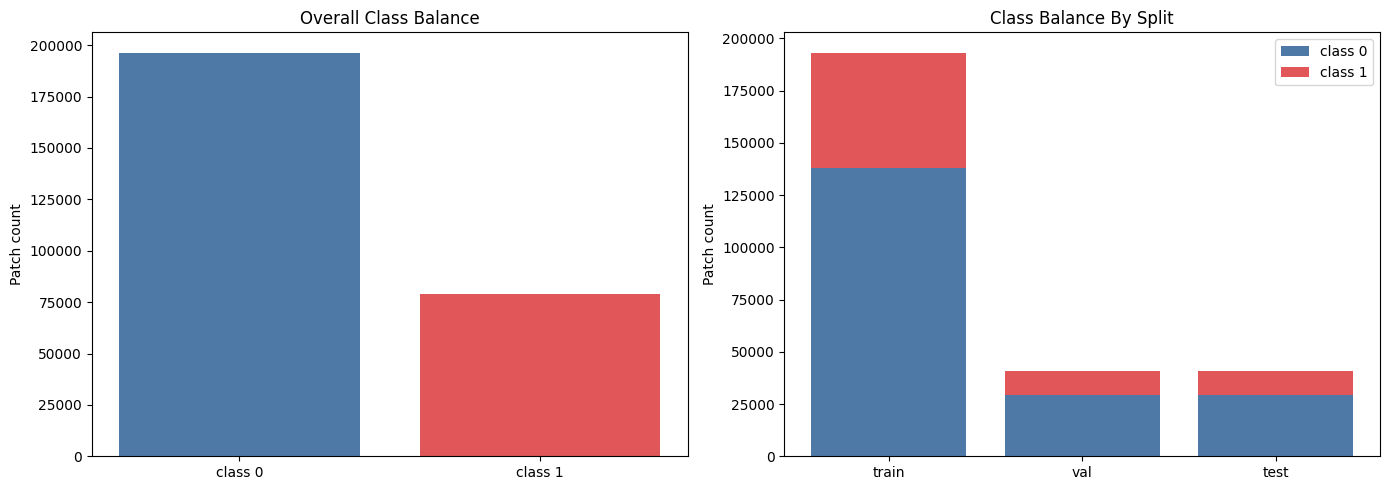

In [24]:
overall_summary = pd.DataFrame(
    [
        {
            'patients': manifest_df['patient_id'].nunique(),
            'patches': len(manifest_df),
            'class_0_patches': int((manifest_df['label'] == 0).sum()),
            'class_1_patches': int((manifest_df['label'] == 1).sum()),
            'class_1_rate': round(float((manifest_df['label'] == 1).mean()), 6),
        }
    ]
)
display(overall_summary)

label_counts = (
    manifest_df['label']
    .value_counts()
    .sort_index()
    .rename(index={0: 'class 0', 1: 'class 1'})
)

split_label_counts = (
    manifest_df.groupby(['split', 'label'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'class 0', 1: 'class 1'})
    .reindex(['train', 'val', 'test'])
)
display(split_label_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(label_counts.index, label_counts.values, color=['#4E79A7', '#E15759'])
axes[0].set_title('Overall Class Balance')
axes[0].set_ylabel('Patch count')

x_positions = np.arange(len(split_label_counts.index))
axes[1].bar(x_positions, split_label_counts['class 0'], label='class 0', color='#4E79A7')
axes[1].bar(
    x_positions,
    split_label_counts['class 1'],
    bottom=split_label_counts['class 0'],
    label='class 1',
    color='#E15759',
)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(split_label_counts.index)
axes[1].set_title('Class Balance By Split')
axes[1].set_ylabel('Patch count')
axes[1].legend()

plt.tight_layout()
plt.show()


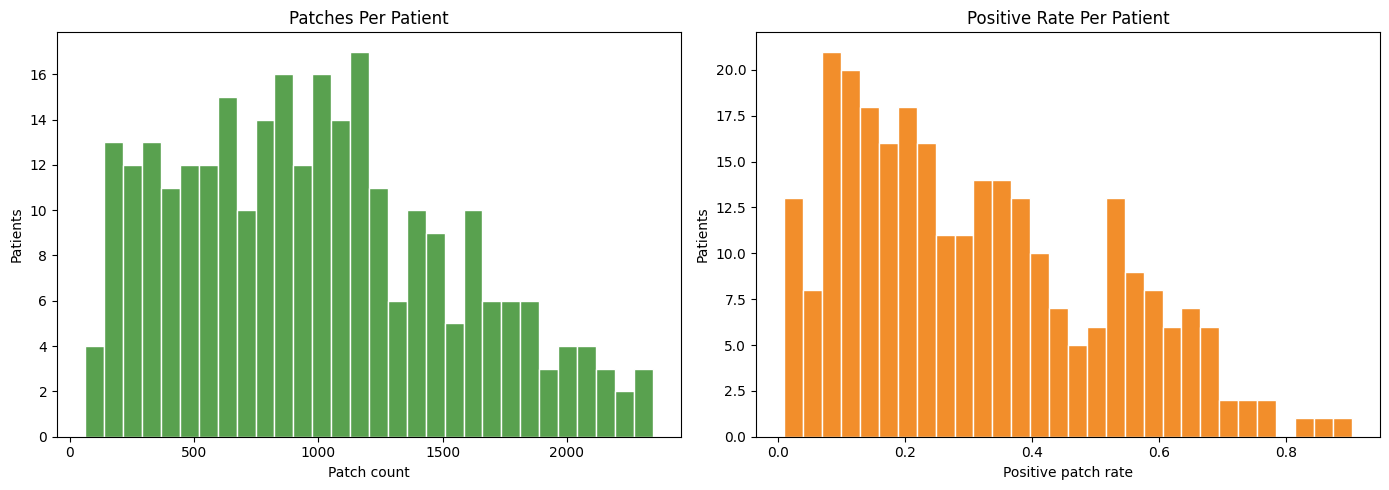

,patient_id,total_patches,positive_patches,negative_patches,positive_rate
217,13693,2345,460,1885,0.196162
268,16550,2301,187,2114,0.081269
104,10288,2278,47,2231,0.020632
119,10308,2268,895,1373,0.394621
16,8975,2208,833,1375,0.377264
269,16551,2183,284,1899,0.130096
70,9323,2180,278,1902,0.127523
93,10272,2175,25,2150,0.011494
91,10268,2109,23,2086,0.010906
261,16165,2108,1174,934,0.556926


,patient_id,total_patches,positive_patches,negative_patches,positive_rate
234,14209,342,309,33,0.903509
60,9262,92,78,14,0.847826
145,12873,281,232,49,0.825623
31,9077,1623,1263,360,0.778189
120,12241,152,115,37,0.756579
253,15633,451,337,114,0.747228
13,8957,110,82,28,0.745455
96,10275,1057,760,297,0.719016
218,13694,1210,870,340,0.719008
249,15514,638,441,197,0.691223


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(patient_df['total_patches'], bins=30, color='#59A14F', edgecolor='white')
axes[0].set_title('Patches Per Patient')
axes[0].set_xlabel('Patch count')
axes[0].set_ylabel('Patients')

axes[1].hist(patient_df['positive_rate'], bins=30, color='#F28E2B', edgecolor='white')
axes[1].set_title('Positive Rate Per Patient')
axes[1].set_xlabel('Positive patch rate')
axes[1].set_ylabel('Patients')

plt.tight_layout()
plt.show()

display(patient_df.sort_values('total_patches', ascending=False).head(10))
display(patient_df.sort_values('positive_rate', ascending=False).head(10))


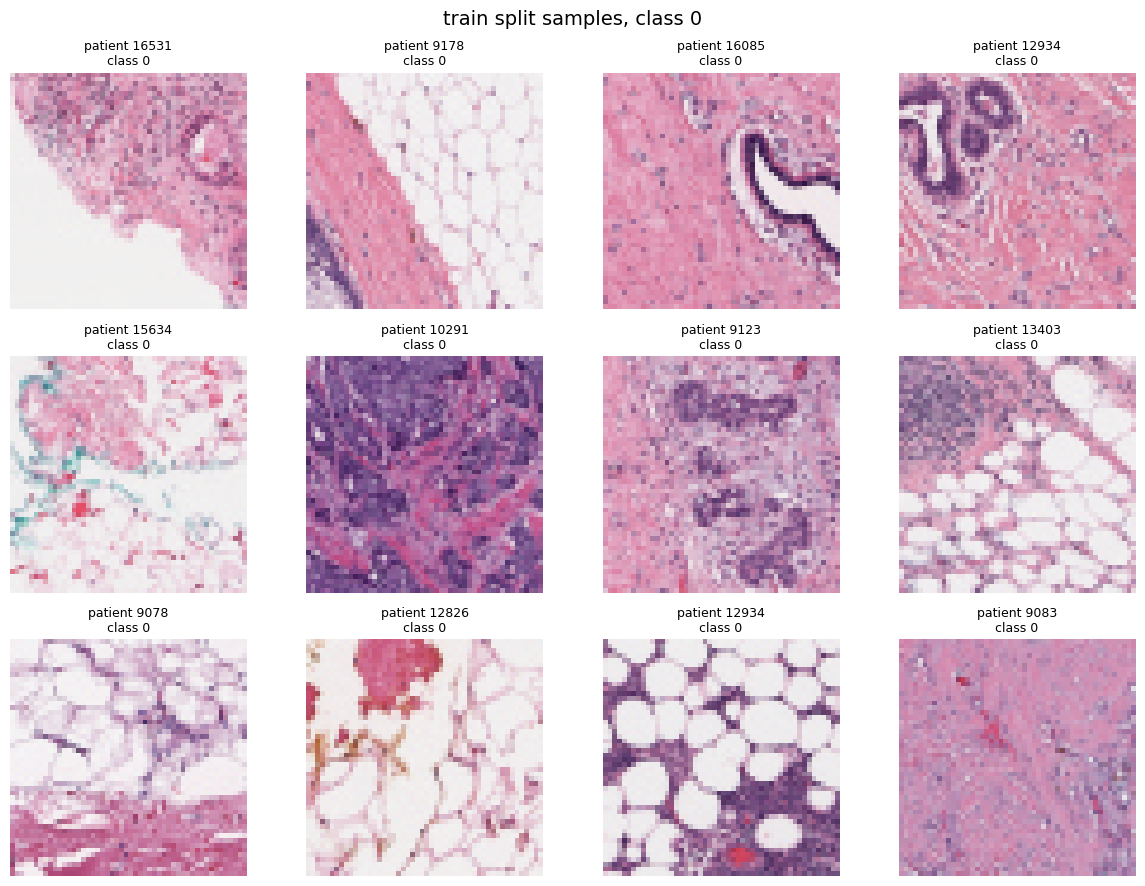

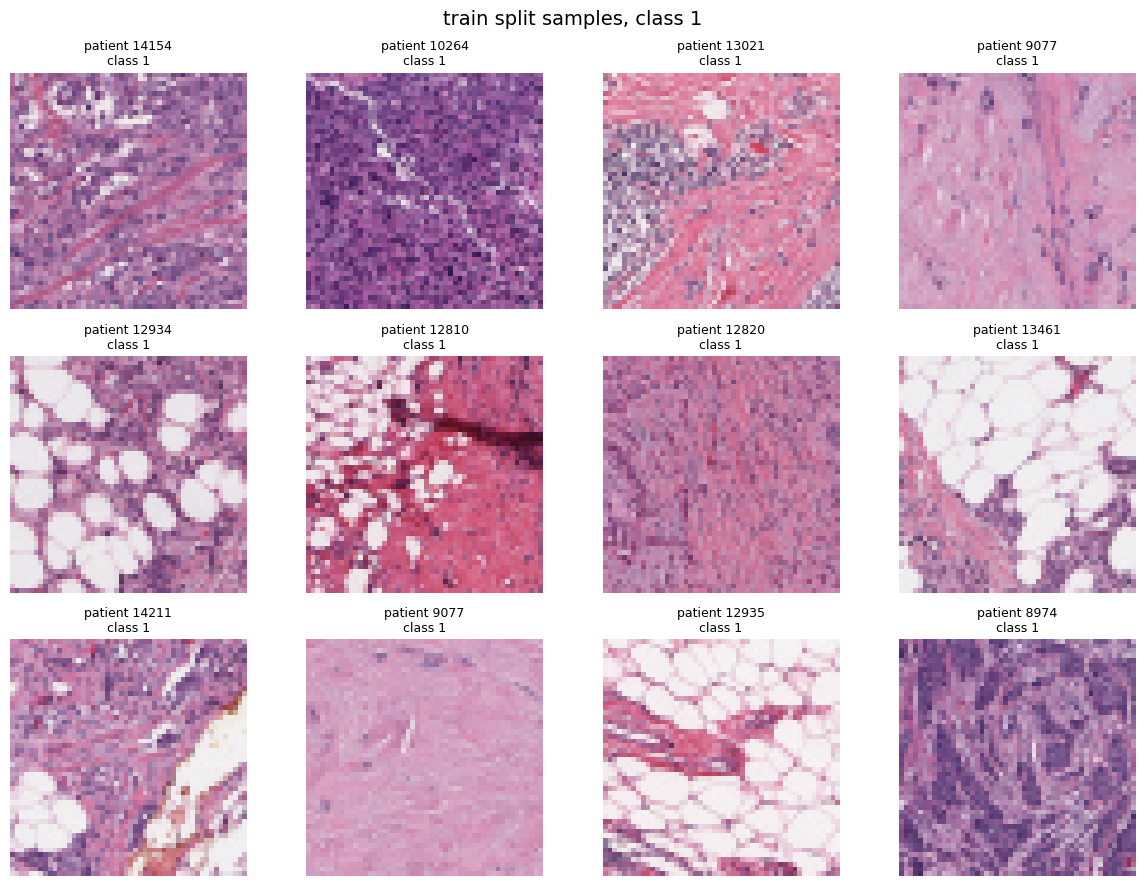

In [26]:
def show_sample_grid(dataframe, split_name, label, n=12, seed=42):
    # Random grids are only for visual sanity checks; they are not used in training.
    subset = dataframe[(dataframe['split'] == split_name) & (dataframe['label'] == label)]
    if subset.empty:
        raise ValueError(f'No rows found for split={split_name}, label={label}.')

    sample_size = min(n, len(subset))
    sample_df = subset.sample(sample_size, random_state=seed)

    cols = 4
    rows = math.ceil(sample_size / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.atleast_1d(axes).reshape(-1)

    for axis, (_, row) in zip(axes, sample_df.iterrows()):
        with Image.open(row['full_path']) as image:
            axis.imshow(image)
        axis.set_title(f"patient {row['patient_id']}\nclass {row['label']}", fontsize=9)
        axis.axis('off')

    for axis in axes[sample_size:]:
        axis.axis('off')

    fig.suptitle(f'{split_name} split samples, class {label}', fontsize=14)
    plt.tight_layout()
    plt.show()


show_sample_grid(manifest_df, split_name='train', label=0, n=12, seed=42)
show_sample_grid(manifest_df, split_name='train', label=1, n=12, seed=42)


In [27]:
def summarize_image_sample(dataframe, sample_size=256, seed=42):
    sample_df = dataframe.sample(min(sample_size, len(dataframe)), random_state=seed)

    sizes = []
    modes = []
    channel_means = []
    channel_stds = []

    for image_path in sample_df['full_path']:
        with Image.open(image_path) as image:
            sizes.append(image.size)
            modes.append(image.mode)
            array = np.asarray(image, dtype=np.float32) / 255.0
            channel_means.append(array.mean(axis=(0, 1)))
            channel_stds.append(array.std(axis=(0, 1)))

    size_counts = pd.Series(sizes).value_counts().rename('count').to_frame()
    mode_counts = pd.Series(modes).value_counts().rename('count').to_frame()
    mean_vector = np.stack(channel_means).mean(axis=0)
    std_vector = np.stack(channel_stds).mean(axis=0)

    return size_counts, mode_counts, mean_vector, std_vector


size_counts, mode_counts, mean_vector, std_vector = summarize_image_sample(
    manifest_df,
    sample_size=256,
    seed=42,
)

display(size_counts)
display(mode_counts)
print('Approximate channel means (R, G, B):', np.round(mean_vector, 4))
print('Approximate channel stds  (R, G, B):', np.round(std_vector, 4))


,count
"(50, 50)",256


,count
RGB,256


Approximate channel means (R, G, B): [0.8052 0.6187 0.7224]
Approximate channel stds  (R, G, B): [0.0912 0.1421 0.1057]


## Next Step

If the class balance, patient distributions, and image samples all look sane, the next notebook should build the baseline training pipeline and read the saved split CSVs from `artifacts/`.
